In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


bike_df = pd.read_csv('../data/bike_train.csv')
print(bike_df.shape)
bike_df.head(3)


(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [4]:
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [ ]:
# 데이터프레임에서 str -> datetime 변환 : pd.to_datetime()
# bike_df["datetime"] = bike_df.datetime.apply(function) function : 적용할 함수 지정
bike_df["datetime"] = bike_df["datetime"].apply(pd.to_datetime) # apply로 함수 적용하는 게 표준.

In [8]:
# datetime feature에서 년, 월, 일, 시간 추출 => 데이터프레임에 추가
bike_df["year"] = bike_df["datetime"].apply(lambda x:x.year)
bike_df["month"] = bike_df["datetime"].apply(lambda x:x.month)
bike_df["day"] = bike_df["datetime"].apply(lambda x:x.day)
bike_df["hour"] = bike_df["datetime"].apply(lambda x:x.hour)

In [9]:
bike_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [10]:
bike_df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour'],
      dtype='str')

In [11]:
# 필요 없는 피처 삭제(누수 차단)
drop_columns = ["datetime","casual","registered"]
bike_df.drop(drop_columns, axis=1, inplace=True)
bike_df.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1


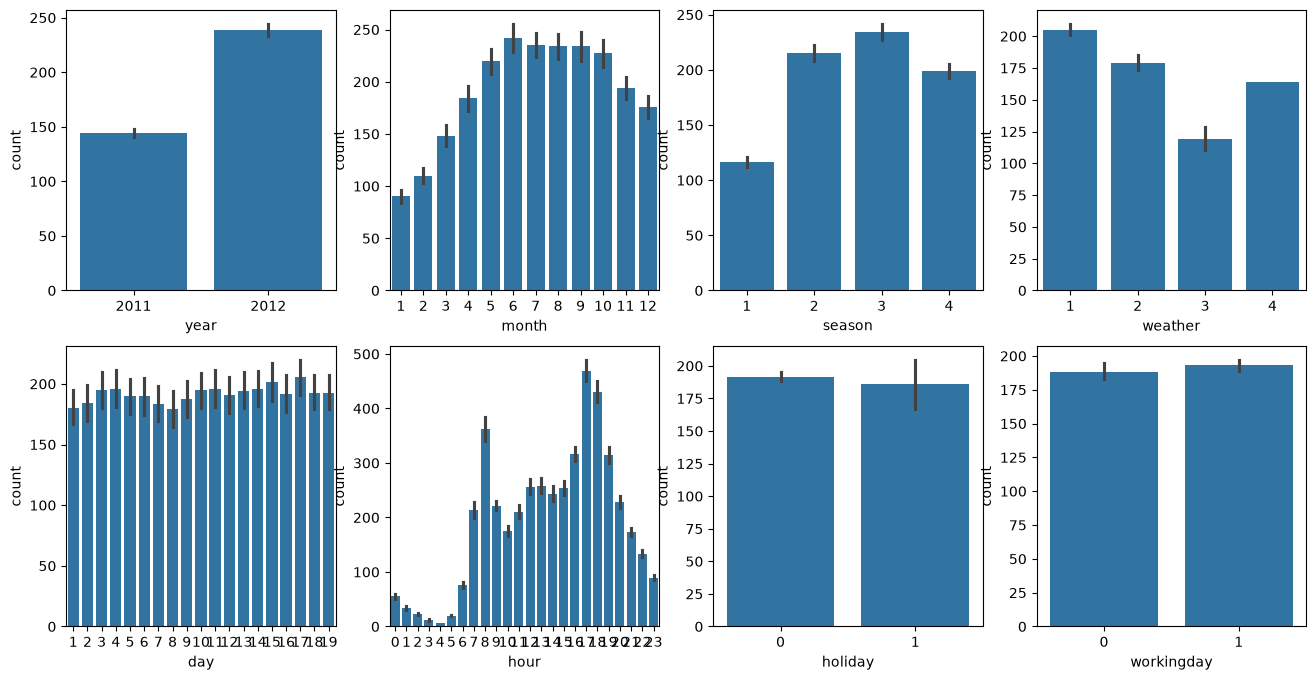

In [12]:
# 주요 컬럼별 원래 답(대여 대수)에 어떻게 분포되어 있는지 시각화
# 총 8개 컬럼: ["year","month","season","weather","day","hour","holiday","workingday"]
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
cat_features = ['year', 'month','season','weather','day', 'hour', 'holiday','workingday']
# cat_features에 있는 모든 칼럼별로 개별 칼럼값에 따른 count의 합을 barplot으로 시각화
for i, feature in enumerate(cat_features):
    row = int(i/4)
    col = i%4
    # 시본의 barplot을 이용해 칼럼값에 따른 count의 합을 표현
    sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row][col])


In [ ]:
# 평가지표 : RMSLE(Root Mean Square Log Error) : 평균제곱오차 -> 로그 -> 루트
# 로그 적용 시 x>0이어야 함.(0이하면 -inf로 감.)
# 목적
# 1. 큰 값의 오차에 대한 과도한 벌점을 줄인다.
# 2. 과소예측(UnderFitting-학습 데이터 학습 후 학습 성능 떨어지는 모델.) 더 큰 벌점 준다.
# 3. target(원래답)이 오른쪽으로 심하게 치우친 데이터 적용.=> 정규분포에 가까워진다.
# MAE : 이상치에 둔감, 해석 직관적(결과가 오차 크기라서?)
# RMSE : 큰 오차에 민감하고, target(원래답)과 단위가 같다는 특징이 있음.
# RMSLE : 로그가 있으며, 상대(비율) 오차를 볼 수 있음. 과소 예측에 더 엄격함(과소예측 방지 가능)
# 과대는 방법 o, 과소는 처음부터 해야 함.

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


# log 값 변환 시 NaN등의 이슈로 log() 가 아닌 log1p() 를 이용하여 RMSLE 계산
def rmsle(y, pred):
    log_y = np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error = (log_y - log_pred) ** 2
    rmsle = np.sqrt(np.mean(squared_error))
    return rmsle


# 사이킷런의 mean_square_error() 를 이용하여 RMSE 계산
def rmse(y,pred):
    return np.sqrt(mean_squared_error(y,pred))


# MSE, RMSE, RMSLE 를 모두 계산
def evaluate_regr(y,pred):
    rmsle_val = rmsle(y,pred)
    rmse_val = rmse(y,pred)
    # MAE 는 scikit learn의 mean_absolute_error() 로 계산
    mae_val = mean_absolute_error(y,pred)
    print('RMSLE: {0:.3f}, RMSE: {1:.3F}, MAE: {2:.3F}'.format(rmsle_val, rmse_val, mae_val))


In [14]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.linear_model import LinearRegression , Ridge , Lasso


y_target = bike_df['count']
X_features = bike_df.drop(['count'],axis=1,inplace=False)


X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0)


lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)


evaluate_regr(y_test ,pred)

RMSLE: 1.165, RMSE: 140.900, MAE: 105.924


In [15]:
def get_top_error_data(y_test, pred, n_tops = 5):
    # DataFrame에 컬럼들로 실제 대여횟수(count)와 예측 값을 서로 비교 할 수 있도록 생성.
    result_df = pd.DataFrame(y_test.values, columns=['real_count'])
    result_df['predicted_count']= np.round(pred)
    result_df['diff'] = np.abs(result_df['real_count'] - result_df['predicted_count'])
    # 예측값과 실제값이 가장 큰 데이터 순으로 출력.
    print(result_df.sort_values('diff', ascending=False)[:n_tops])
   
get_top_error_data(y_test,pred,n_tops=5)

# diff 500개 이상 차이.

      real_count  predicted_count   diff
1618         890            322.0  568.0
966          884            327.0  557.0
3151         798            241.0  557.0
412          745            194.0  551.0
2817         856            310.0  546.0


<Axes: >

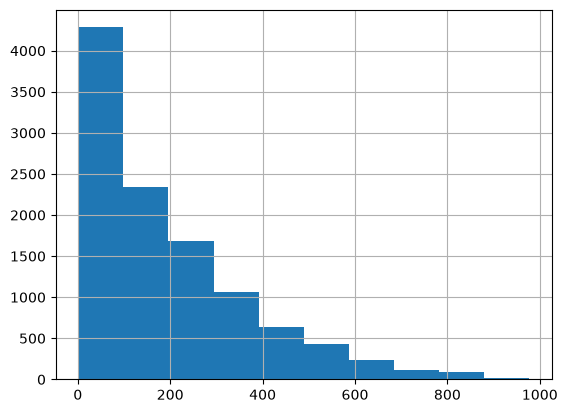

In [16]:
# label 문제점 파악
y_target.hist()

# 답이 한 쪽으로 쏠림. 오차가 클 수 있음.

<Axes: >

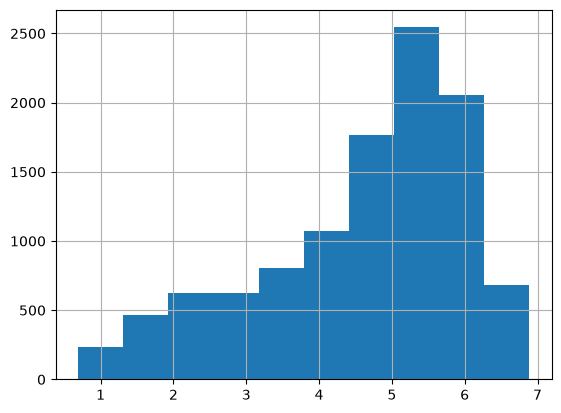

In [17]:
y_log_transform = np.log1p(y_target)
y_log_transform.hist()


In [19]:
# 타깃 칼럼인 count 값을 log1p로 로그 변환
y_target_log = np.log1p(y_target)


# 로그 변환된 y_target_log를 반영하여 학습/테스트 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target_log, test_size=0.3, random_state=0)
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)


# 테스트 데이터 셋의 Target 값은 Log 변환되었으므로 다시 expm1를 이용하여 원래 scale로 변환
# (로그 -> 지수로 변환(원래 값으로) + 로그 바꿀 때 +1 했으니 다시 -1)
y_test_exp = np.expm1(y_test)


# 예측 값 역시 Log 변환된 타깃 기반으로 학습되어 예측되었으므로 다시 expm1으로 scale변환
# (로그 -> 지수로 변환(원래 값으로) + 로그 바꿀 때 +1 했으니 다시 -1)
pred_exp = np.expm1(pred)


evaluate_regr(y_test_exp ,pred_exp)

# RMSLE: 1.165, RMSE: 140.900, MAE: 105.924

RMSLE: 1.017, RMSE: 162.594, MAE: 109.286


<Axes: ylabel='None'>

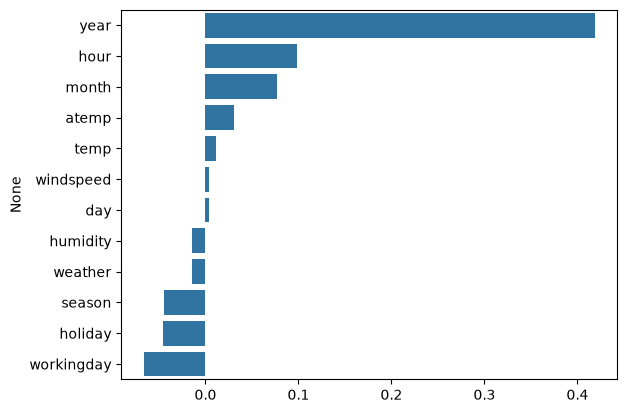

In [20]:
# 피처 중요도 확인 : coef_: 회귀계수 값(w, 가중치)이 있다. 그 값이 피처의 영향력
coef = pd.Series(lr_reg.coef_, index=X_features.columns)    
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

# year가 제일 중요도 큼. year는 2011, 2012. hour는 0~23. month는 1~12. 값의 범위가 다름. 원-핫 인코딩해야.
# year 커서 중요하게 받아들임.
# temp, atemp 등은 연속값이라 논외. 
# 카테고리형 데이터(year,hour,month, day,weather,season,holiday,workingday) 숫자 크기에 의미가 없는 값.

In [21]:
# 원-핫 인코딩
# 'year', month', 'day', hour'등의 피처들을 One Hot Encoding
X_features_ohe = pd.get_dummies(X_features, columns=['year', 'month','day', 'hour', 'holiday',
                                              'workingday','season','weather'])


In [22]:
X_features_ohe.head(3)

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,9.84,14.395,81,0.0,True,False,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
1,9.02,13.635,80,0.0,True,False,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
2,9.02,13.635,80,0.0,True,False,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False


In [23]:
# 원-핫 인코딩이 적용된 feature 데이터 세트 기반으로 학습/예측 데이터 분할.
X_train, X_test, y_train, y_test = train_test_split(X_features_ohe, y_target_log,
                                                    test_size=0.3, random_state=0)


# 모델과 학습/테스트 데이터 셋을 입력하면 성능 평가 수치를 반환
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if is_expm1 :
        y_test = np.expm1(y_test)
        pred = np.expm1(pred)
    print('###',model.__class__.__name__,'###')
    evaluate_regr(y_test, pred)
# end of function get_model_predict    


# model 별로 평가 수행
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)


for model in [lr_reg, ridge_reg, lasso_reg]:
    get_model_predict(model,X_train, X_test, y_train, y_test,is_expm1=True)


### LinearRegression ###
RMSLE: 0.590, RMSE: 97.688, MAE: 63.382
### Ridge ###
RMSLE: 0.590, RMSE: 98.529, MAE: 63.893
### Lasso ###
RMSLE: 0.635, RMSE: 113.219, MAE: 72.803


<Axes: ylabel='None'>

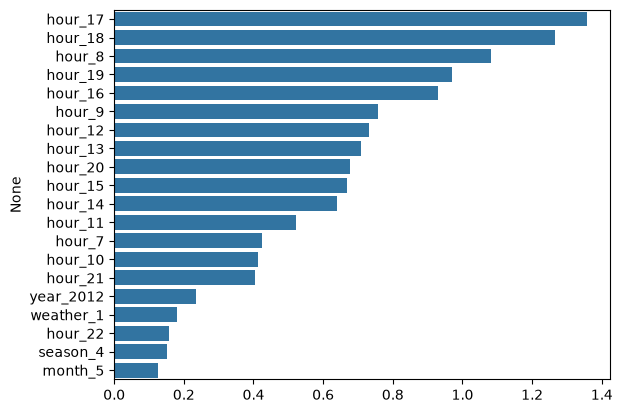

In [24]:
coef = pd.Series(lr_reg.coef_ , index=X_features_ohe.columns)
coef_sort = coef.sort_values(ascending=False)[:20]
sns.barplot(x=coef_sort.values , y=coef_sort.index)


In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# 랜덤 포레스트, GBM, XGBoost, LightGBM model 별로 평가 수행
rf_reg = RandomForestRegressor(n_estimators=500)
gbm_reg = GradientBoostingRegressor(n_estimators=500)
xgb_reg = XGBRegressor(n_estimators=500)
lgbm_reg = LGBMRegressor(n_estimators=500)


for model in [rf_reg, gbm_reg, xgb_reg, lgbm_reg]:
    # XGBoost의 경우 DataFrame이 입력 될 경우 버전에 따라 오류 발생 가능. ndarray로 변환.
    get_model_predict(model,X_train.values, X_test.values, y_train.values, y_test.values,is_expm1=True)


### RandomForestRegressor ###
RMSLE: 0.354, RMSE: 49.998, MAE: 30.997
### GradientBoostingRegressor ###
RMSLE: 0.330, RMSE: 53.331, MAE: 32.738
### XGBRegressor ###
RMSLE: 0.339, RMSE: 51.475, MAE: 31.357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 348
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 72
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE: 0.319, RMSE: 47.215, MAE: 29.029


In [ ]:
# 정리
# 회귀모델(1~3번)
# 1. 베이스 모델 학습-평가: 1.1
# 2. target 로그 변환: 1.0
# 3. 원-핫 인코딩: 0.59
# 트리 모델(4~)
# 4. 로그변환, 원핫 적용된 모델을 트리 변경: 0.31

In [ ]:
# 개선 방향
# 1. 하이퍼 파라미터 튜닝: learning-rate, max-depth, GridSearchCV
# 2. windspeed, humidity 피처의 0 값 처리
# 3. day feature drop
# 4. 요일(dayofweek) 추가 

In [26]:
bike_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,191.574132,2011.501929,6.521495,9.992559,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,181.144454,0.500019,3.444373,5.476608,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,42.000000,2011.000000,4.000000,5.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,145.000000,2012.000000,7.000000,10.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,284.000000,2012.000000,10.000000,15.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,977.000000,2012.000000,12.000000,19.000000,23.000000


---
#### 회귀 문제 진행 순서
1. 데이터 파악: info()로 결측, 타입, 컬럼의 의미 이해
2. 데이터 누수 제거: 예측 시점에 알 수 없는 피처(누수) 제거. (casual, registed) 대여(count)는 바로 확인이 가능하지만 casual인지 registed인지 알 수 없음.(그 나라 시스템상)
3. 피처 엔지니어링: datetime -> year, month, day, hour 로 분해.
4. 탐색적 분석(EDA): barplot 시각화로 피처-레이블 관계 확인. 쓸모 없는 피처 식별
5. 평가지표 결정: 문제 성격에 맞는 지표 선택(RMSLE)
6. 기준 모델 수립: LinearRegression으로 최소 성능 확인.
7. 타깃(원래답) 변환: 로그변환
8. 범주형(카테고리형) 데이터 원핫: 인코딩
9. 모델 고도화: 트리 모델 사용
10. 하이퍼 파라미터 튜닝: 최적화
---